In [21]:
from sklearn.datasets import fetch_openml
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
dataset = fetch_openml(name="qsar-biodeg", as_frame=True, parser="auto")

X = dataset.data.copy()
y = dataset.target.astype(str)

print(X.shape)
print(y.shape)
print(y.value_counts())

(1055, 41)
(1055,)
Class
1    699
2    356
Name: count, dtype: int64


D:\Code\biodegradability-project\.venv\Lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name qsar-biodeg exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1494
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=46952

  warn(warning_msg)


In [23]:
descriptor_names = [
    "SpMax_L", "J_Dz(e)", "nHM", "F01[N-N]", "F04[C-N]", "NssssC", "nCb-", "C%",
    "nCp", "nO", "F03[C-N]", "SdssC", "HyWi_B(m)", "LOC", "SM6_L", "F03[C-O]",
    "Me", "Mi", "nN-N", "nArNO2", "nCRX3", "SpPosA_B(p)", "nCIR", "B01[C-Br]",
    "B03[C-Cl]", "N-073", "SpMax_A", "Psi_i_1d", "B04[C-Br]", "SdO", "TI2_L",
    "nCrt", "C-026", "F02[C-N]", "nHDon", "SpMax_B(m)", "Psi_i_A", "nN",
    "SM6_B(m)", "nArCOOR", "nX"
]

X.columns = descriptor_names
print(X.head())

   SpMax_L  J_Dz(e)  nHM  F01[N-N]  F04[C-N]  NssssC  nCb-    C%  nCp  nO  \
0    3.919   2.6909    0         0         0       0     0  31.4    2   0   
1    4.170   2.1144    0         0         0       0     0  30.8    1   1   
2    3.932   3.2512    0         0         0       0     0  26.7    2   4   
3    3.000   2.7098    0         0         0       0     0  20.0    0   2   
4    4.236   3.3944    0         0         0       0     0  29.4    2   4   

   ...  nCrt  C-026  F02[C-N]  nHDon  SpMax_B(m)  Psi_i_A  nN  SM6_B(m)  \
0  ...     0      0         0      0       2.949    1.591   0     7.253   
1  ...     0      0         0      0       3.315    1.967   0     7.257   
2  ...     0      0         0      1       3.076    2.417   0     7.601   
3  ...     0      0         0      1       3.046    5.000   0     6.690   
4  ...     0      0         0      0       3.351    2.405   0     8.003   

   nArCOOR  nX  
0        0   0  
1        0   0  
2        0   0  
3        0   0  
4

In [24]:
y_named = y.map({"1": "NRB", "2": "RB"})

print(y_named.head())
print(y_named.value_counts())

0    RB
1    RB
2    RB
3    RB
4    RB
Name: Class, dtype: str
Class
NRB    699
RB     356
Name: count, dtype: int64


In [25]:
df = X.copy()
df["Class"] = y_named

print(df.shape)
print(df.head())

(1055, 42)
   SpMax_L  J_Dz(e)  nHM  F01[N-N]  F04[C-N]  NssssC  nCb-    C%  nCp  nO  \
0    3.919   2.6909    0         0         0       0     0  31.4    2   0   
1    4.170   2.1144    0         0         0       0     0  30.8    1   1   
2    3.932   3.2512    0         0         0       0     0  26.7    2   4   
3    3.000   2.7098    0         0         0       0     0  20.0    0   2   
4    4.236   3.3944    0         0         0       0     0  29.4    2   4   

   ...  C-026  F02[C-N]  nHDon  SpMax_B(m)  Psi_i_A  nN  SM6_B(m)  nArCOOR  \
0  ...      0         0      0       2.949    1.591   0     7.253        0   
1  ...      0         0      0       3.315    1.967   0     7.257        0   
2  ...      0         0      1       3.076    2.417   0     7.601        0   
3  ...      0         0      1       3.046    5.000   0     6.690        0   
4  ...      0         0      0       3.351    2.405   0     8.003        0   

   nX  Class  
0   0     RB  
1   0     RB  
2   0     RB

In [26]:
X_model = df.drop(columns="Class")
y_model = df["Class"].map({"NRB": 0, "RB": 1})

print(X_model.shape)
print(y_model.shape)
print(y_model.value_counts())

(1055, 41)
(1055,)
Class
0    699
1    356
Name: count, dtype: int64


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

X_train shape: (844, 41)
X_test shape: (211, 41)
y_train shape: (844,)
y_test shape: (211,)

Train label distribution:
Class
0    559
1    285
Name: count, dtype: int64

Test label distribution:
Class
0    140
1     71
Name: count, dtype: int64


In [28]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.8578199052132701

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       140
           1       0.78      0.80      0.79        71

    accuracy                           0.86       211
   macro avg       0.84      0.84      0.84       211
weighted avg       0.86      0.86      0.86       211


Confusion Matrix:
[[124  16]
 [ 14  57]]


In [29]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Accuracy: 0.8151658767772512

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86       140
           1       0.74      0.69      0.72        71

    accuracy                           0.82       211
   macro avg       0.80      0.78      0.79       211
weighted avg       0.81      0.82      0.81       211


Confusion Matrix:
[[123  17]
 [ 22  49]]


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8767772511848341

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       140
           1       0.89      0.72      0.80        71

    accuracy                           0.88       211
   macro avg       0.88      0.84      0.85       211
weighted avg       0.88      0.88      0.87       211


Confusion Matrix:
[[134   6]
 [ 20  51]]


In [31]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "F1_class_0": [
        classification_report(y_test, y_pred_lr, output_dict=True)["0"]["f1-score"],
        classification_report(y_test, y_pred_tree, output_dict=True)["0"]["f1-score"],
        classification_report(y_test, y_pred_rf, output_dict=True)["0"]["f1-score"]
    ],
    "F1_class_1": [
        classification_report(y_test, y_pred_lr, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_tree, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["f1-score"]
    ],
    "Recall_class_1": [
        classification_report(y_test, y_pred_lr, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_tree, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["recall"]
    ]
}).round(3)

model_comparison

,Model,Accuracy,F1_class_0,F1_class_1,Recall_class_1
0,Logistic Regression,0.858,0.892,0.792,0.803
1,Decision Tree,0.815,0.863,0.715,0.690
2,Random Forest,0.877,0.912,0.797,0.718


Among the three baseline models, Random Forest achieved the highest overall accuracy and therefore performed best overall. Logistic Regression also showed strong performance and achieved the highest recall for the RB class, indicating better sensitivity to readily biodegradable compounds. By contrast, Decision Tree performed the worst overall, likely due to the instability and overfitting tendency of a single tree.

In [32]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_tree = confusion_matrix(y_test, y_pred_tree)
cm_rf = confusion_matrix(y_test, y_pred_rf)

error_analysis = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "TN_class0_correct": [cm_lr[0, 0], cm_tree[0, 0], cm_rf[0, 0]],
    "FP_class0_to_1": [cm_lr[0, 1], cm_tree[0, 1], cm_rf[0, 1]],
    "FN_class1_to_0": [cm_lr[1, 0], cm_tree[1, 0], cm_rf[1, 0]],
    "TP_class1_correct": [cm_lr[1, 1], cm_tree[1, 1], cm_rf[1, 1]]
}).round(3)

error_analysis

,Model,TN_class0_correct,FP_class0_to_1,FN_class1_to_0,TP_class1_correct
0,Logistic Regression,124,16,14,57
1,Decision Tree,123,17,22,49
2,Random Forest,134,6,20,51


## Error Analysis Based on Confusion Matrices

The confusion-matrix-based error analysis shows that Random Forest achieves the best overall classification performance mainly because it identifies the NRB class more accurately, with the highest number of correct NRB predictions and the fewest NRB-to-RB errors. In contrast, Logistic Regression performs best on the RB class, with the smallest number of RB samples misclassified as NRB and the highest number of correctly identified RB samples. Decision Tree performs worst overall, especially because it misses more true RB samples than the other two models.

These results show that model evaluation should not rely on accuracy alone. Although Random Forest has the highest overall accuracy, Logistic Regression remains highly competitive when recall for the RB class is especially important.

In [33]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns)
rf_importance = rf_importance.sort_values(ascending=False)

rf_importance.head(10)

SpMax_B(m)     0.084141
SM6_B(m)       0.071262
SpMax_L        0.068277
SpPosA_B(p)    0.067131
SpMax_A        0.064243
HyWi_B(m)      0.037637
F02[C-N]       0.036014
SM6_L          0.033414
Psi_i_A        0.033111
J_Dz(e)        0.031418
dtype: float64

## Random Forest Feature Importance

The Random Forest feature importance results show that several top-ranked descriptors, including SpMax_B(m), SM6_B(m), SpMax_L, SpPosA_B(p), SpMax_A, HyWi_B(m), and SM6_L, play important roles in the final classification. Notably, many of these features were also identified in the earlier EDA-based screening, which suggests good consistency between preliminary feature screening and model-based interpretation.

At the same time, a few descriptors such as F02[C-N], Psi_i_A, and J_Dz(e) appear among the top model-based features even though they were not among the top-ranked features in the earlier mean-difference screening. This suggests that some descriptors may become more useful when nonlinear interactions are considered by the model.

Overall, the results indicate that biodegradability prediction depends not only on a few interpretable descriptors, but also on a broader set of abstract QSAR descriptors that contribute jointly to model performance.

In [34]:
candidate_features = [
    'SpMax_L',
    'SpMax_A',
    'SpPosA_B(p)',
    'SM6_B(m)',
    'HyWi_B(m)',
    'SM6_L',
    'nCb-',
    'C-026',
    'nHM',
    'SpMax_B(m)'
]

In [35]:
eda_top10 = set(candidate_features)
rf_top10 = set(rf_importance.head(10).index.tolist())

common_features = sorted(eda_top10 & rf_top10)
eda_only = sorted(eda_top10 - rf_top10)
rf_only = sorted(rf_top10 - eda_top10)

print("Common features:", common_features)
print("\nEDA-only features:", eda_only)
print("\nRF-only features:", rf_only)

Common features: ['HyWi_B(m)', 'SM6_B(m)', 'SM6_L', 'SpMax_A', 'SpMax_B(m)', 'SpMax_L', 'SpPosA_B(p)']

EDA-only features: ['C-026', 'nCb-', 'nHM']

RF-only features: ['F02[C-N]', 'J_Dz(e)', 'Psi_i_A']


In [36]:
rf_top10_df = rf_importance.head(10).reset_index()
rf_top10_df.columns = ["Feature", "Importance"]
rf_top10_df

,Feature,Importance
0,SpMax_B(m),0.084141
1,SM6_B(m),0.071262
2,SpMax_L,0.068277
3,SpPosA_B(p),0.067131
4,SpMax_A,0.064243
5,HyWi_B(m),0.037637
6,F02[C-N],0.036014
7,SM6_L,0.033414
8,Psi_i_A,0.033111
9,J_Dz(e),0.031418


In [37]:
feature_overlap_df = pd.DataFrame({
    "Common_features": pd.Series(common_features),
    "EDA_only": pd.Series(eda_only),
    "RF_only": pd.Series(rf_only)
})

feature_overlap_df

,Common_features,EDA_only,RF_only
0,HyWi_B(m),C-026,F02[C-N]
1,SM6_B(m),nCb-,J_Dz(e)
2,SM6_L,nHM,Psi_i_A
3,SpMax_A,NaN,NaN
4,SpMax_B(m),NaN,NaN
5,SpMax_L,NaN,NaN
6,SpPosA_B(p),NaN,NaN


In [38]:
lr_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr_scaled.fit(X_train, y_train)

y_pred_lr_scaled = lr_scaled.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr_scaled))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_scaled))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_scaled))

Accuracy: 0.8625592417061612

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       140
           1       0.80      0.79      0.79        71

    accuracy                           0.86       211
   macro avg       0.85      0.84      0.85       211
weighted avg       0.86      0.86      0.86       211


Confusion Matrix:
[[126  14]
 [ 15  56]]


In [40]:
lr_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

lr_balanced.fit(X_train, y_train)

y_pred_lr_balanced = lr_balanced.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr_balanced))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_balanced))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_balanced))

Accuracy: 0.8436018957345972

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       140
           1       0.72      0.89      0.79        71

    accuracy                           0.84       211
   macro avg       0.83      0.85      0.83       211
weighted avg       0.86      0.84      0.85       211


Confusion Matrix:
[[115  25]
 [  8  63]]


In [41]:
model_comparison_final = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Scaled Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_lr_scaled),
        accuracy_score(y_test, y_pred_lr_balanced),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "F1_class_0": [
        classification_report(y_test, y_pred_lr, output_dict=True)["0"]["f1-score"],
        classification_report(y_test, y_pred_lr_scaled, output_dict=True)["0"]["f1-score"],
        classification_report(y_test, y_pred_lr_balanced, output_dict=True)["0"]["f1-score"],
        classification_report(y_test, y_pred_tree, output_dict=True)["0"]["f1-score"],
        classification_report(y_test, y_pred_rf, output_dict=True)["0"]["f1-score"]
    ],
    "F1_class_1": [
        classification_report(y_test, y_pred_lr, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_lr_scaled, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_lr_balanced, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_tree, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["f1-score"]
    ],
    "Recall_class_1": [
        classification_report(y_test, y_pred_lr, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_lr_scaled, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_lr_balanced, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_tree, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["recall"]
    ]
}).round(3)

model_comparison_final

,Model,Accuracy,F1_class_0,F1_class_1,Recall_class_1
0,Logistic Regression,0.858,0.892,0.792,0.803
1,Scaled Logistic Regression,0.863,0.897,0.794,0.789
2,Balanced Logistic Regression,0.844,0.875,0.792,0.887
3,Decision Tree,0.815,0.863,0.715,0.690
4,Random Forest,0.877,0.912,0.797,0.718


## Model Improvement Experiment
The final model comparison shows that different models perform best under different evaluation priorities. Random Forest achieved the highest overall accuracy (0.877) and the strongest overall classification performance. Balanced Logistic Regression achieved the highest recall for the RB class (0.887), which means it was the most effective model for identifying readily biodegradable compounds. 

Compared with the original Logistic Regression, feature standardization slightly improved overall accuracy but slightly reduced recall for the RB class. This suggests that scaling provides only a limited benefit in this dataset. By contrast, adding class balancing substantially improved RB recall, although this came at the cost of lower overall accuracy. Therefore, the final results reveal a clear trade-off between overall classification accuracy and minority-class sensitivity.

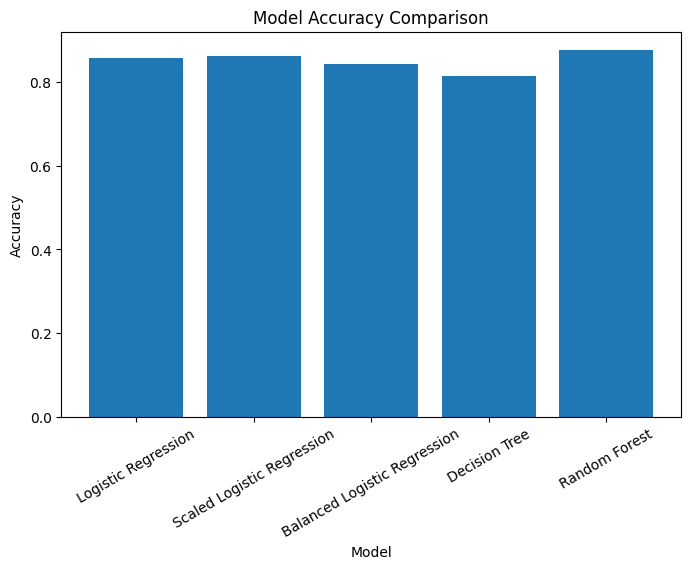

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(model_comparison_final["Model"], model_comparison_final["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

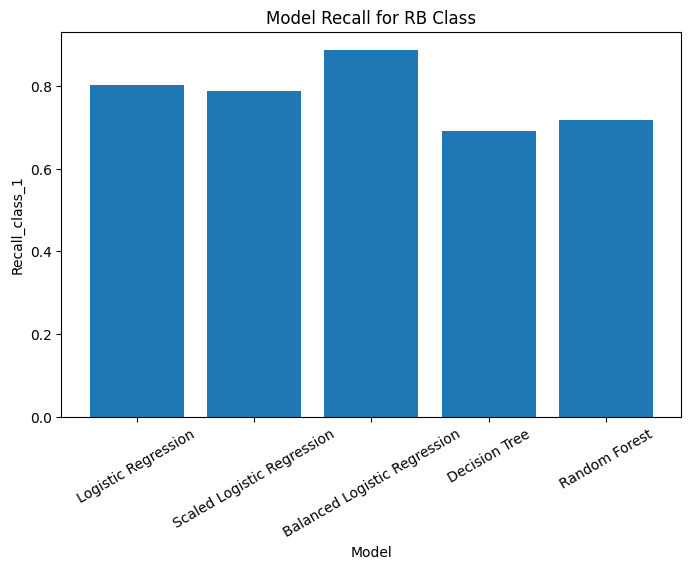

In [43]:
plt.figure(figsize=(8, 5))
plt.bar(model_comparison_final["Model"], model_comparison_final["Recall_class_1"])
plt.title("Model Recall for RB Class")
plt.xlabel("Model")
plt.ylabel("Recall_class_1")
plt.xticks(rotation=30)
plt.show()

## Results Summary

The baseline model comparison shows that Random Forest achieves the highest overall accuracy, while Balanced Logistic Regression achieves the highest recall for the RB class. This means that Random Forest performs best overall, whereas Balanced Logistic Regression is more sensitive to readily biodegradable compounds.

The confusion-matrix-based error analysis further shows that Random Forest performs especially well on the NRB class, whereas Balanced Logistic Regression misses fewer true RB samples. In other words, the two models have slightly different strengths.

The feature importance analysis indicates that the final prediction relies heavily on several abstract QSAR descriptors, such as SpMax_B(m), SM6_B(m), SpMax_L, SpPosA_B(p), and SpMax_A. At the same time, there is some overlap between the EDA top features and the Random Forest top features, which suggests good consistency between preliminary screening and model-based interpretation.
The visual comparison of model performance highlights a clear trade-off between overall accuracy and RB-class sensitivity. Random Forest achieved the highest overall accuracy, whereas Balanced Logistic Regression achieved the highest recall for the RB class. This suggests that the most suitable model depends on the evaluation priority: Random Forest is preferable for stronger overall classification, while Balanced Logistic Regression is preferable when identifying as many RB compounds as possible is more important.

Overall, the project results suggest that biodegradability prediction depends on a combination of multiple molecular descriptors, rather than any single feature alone.